# Lab 3: Feature Engineering and Data Preprocessing on Titanic Dataset

This notebook explores key concepts in feature engineering and data preprocessing using the Titanic dataset. We'll cover:

1. Feature Engineering Intuition
2. Data Categories and Encoding Categorical Variables
3. Scaling, Transformations, and Leakage Risks

Through hands-on examples, you'll learn to apply these techniques to improve machine learning models.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Set up plotting
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [37]:
# Load the Titanic dataset
df = sns.load_dataset('titanic')

# Display first few rows
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [38]:
# Create a data dictionary for column descriptions
data_dictionary = {
    'survived': 'Survival status (0 = No, 1 = Yes)',
    'pclass': 'Ticket class (1 = 1st class, 2 = 2nd class, 3 = 3rd class)',
    'sex': 'Sex of passenger',
    'age': 'Age in years',
    'sibsp': 'Number of siblings/spouses aboard the Titanic',
    'parch': 'Number of parents/children aboard the Titanic',
    'fare': 'Passenger fare',
    'embarked': 'Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)',
    'class': 'Same as pclass but as categorical (First, Second, Third)',
    'who': 'Demographic category (man, woman, child)',
    'adult_male': 'Whether passenger is an adult male (boolean)',
    'deck': 'Deck where passenger was located (A, B, C, D, E, F, G)',
    'embark_town': 'Full name of embarkation port',
    'alive': 'Same as survived but as string (no, yes)',
    'alone': 'Whether passenger was traveling alone (boolean)'
}

print("Titanic Dataset Column Descriptions:")
print("=" * 50)
for col, desc in data_dictionary.items():
    print(f"{col:12}: {desc}")

Titanic Dataset Column Descriptions:
survived    : Survival status (0 = No, 1 = Yes)
pclass      : Ticket class (1 = 1st class, 2 = 2nd class, 3 = 3rd class)
sex         : Sex of passenger
age         : Age in years
sibsp       : Number of siblings/spouses aboard the Titanic
parch       : Number of parents/children aboard the Titanic
fare        : Passenger fare
embarked    : Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)
class       : Same as pclass but as categorical (First, Second, Third)
who         : Demographic category (man, woman, child)
adult_male  : Whether passenger is an adult male (boolean)
deck        : Deck where passenger was located (A, B, C, D, E, F, G)
embark_town : Full name of embarkation port
alive       : Same as survived but as string (no, yes)
alone       : Whether passenger was traveling alone (boolean)


## 1. Feature Engineering Intuition

Feature engineering is the process of creating new features or modifying existing ones to improve model performance. It's often said that "feature engineering is the art of turning data into information."

### Why is Feature Engineering Important?
- Raw data may not capture all relevant information
- Models learn patterns from features, so better features = better patterns
- Can help models generalize better to unseen data
- Reduces the need for complex models

### Key Principles:
1. **Domain Knowledge**: Use understanding of the problem domain
2. **Creativity**: Think of new ways to represent information
3. **Iterative Process**: Test and refine features
4. **Avoid Leakage**: Don't use future information to predict past events

In [39]:
# Explore the dataset

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [23]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [25]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


### Exploratory data analysis

### Exploratory data analysis

Before diving into feature engineering, let's explore the data to understand patterns and relationships that can inspire new features. This analysis will help you think creatively about what information might be useful for predicting survival.

**Questions to consider:**
- What patterns do you notice in the data?
- Which features seem most related to survival?
- What new features could you create from existing ones?
- How might social status, family connections, or travel circumstances affect survival?

In [29]:
# Survival rate by different categories
print("\nSurvival rates by key categories:")

print("By Sex:")
print(df.groupby('sex')['survived'].mean())

print("\nBy Class:")
print(df.groupby('class')['survived'].mean())

print("\nBy Embarked:")
print(df.groupby('embarked')['survived'].mean())


Survival rates by key categories:
By Sex:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

By Class:
class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

By Embarked:
embarked
C    0.553571
Q    0.389610
S    0.336957
Name: survived, dtype: float64


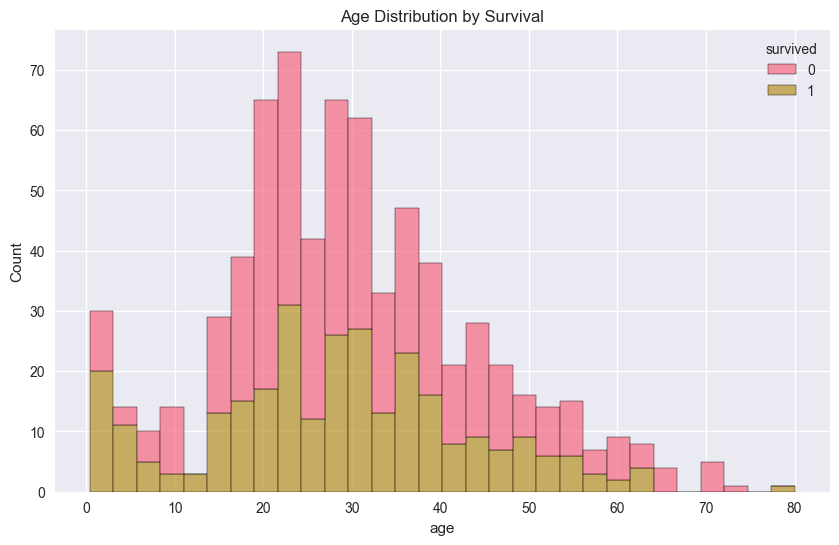

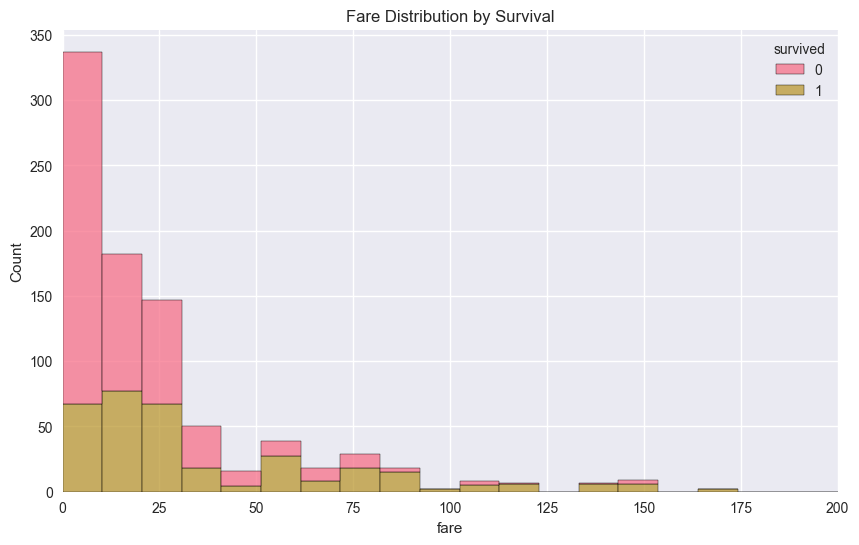

In [27]:
# Age distribution by survival
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='survived', multiple='stack', bins=30)
plt.title('Age Distribution by Survival')
plt.show()

# Fare distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='fare', hue='survived', multiple='stack', bins=50)
plt.title('Fare Distribution by Survival')
plt.xlim(0, 200)  # Limit to see main distribution
plt.show()

In [ ]:
# Cross-tabulations to understand relationships
print("Survival by class and sex:")
pd.crosstab(df['class'], df['sex'], values=df['survived'], aggfunc='mean')


Survival by class and sex:


sex,female,male
class,,
First,0.968085,0.368852
Second,0.921053,0.157407
Third,0.500000,0.135447


In [35]:
# Family relationships
print("\nFamily size distribution:")
df.groupby(['sibsp', 'parch']).size().head(10)


Family size distribution:


sibsp  parch
0      0        537
       1         38
       2         29
       3          1
       4          1
       5          2
1      0        123
       1         57
       2         19
       3          3
dtype: int64

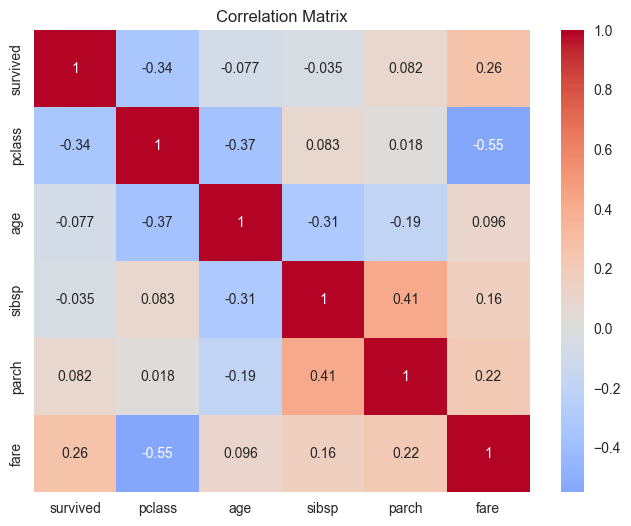

In [34]:
# Correlation matrix for numerical features
numerical_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

### Feature Engineering Inspiration

Based on the EDA above, what new features can you think of? Here are some ideas to consider:

1. **Family-based features**: Family size seems important. What about "large family" vs "small family"? Or "has siblings" vs "only child"?

2. **Age-wealth interactions**: Children in first class vs third class might have different survival rates. Could you create an "age_class_interaction" feature?

3. **Travel group features**: People traveling alone vs with family. But what about friends or colleagues traveling together?

4. **Deck/Location features**: The 'deck' column has many missing values, but could indicate location on ship and access to lifeboats.

5. **Name-based features**: Names might indicate nationality, social status, or marital status beyond just titles.

6. **Fare-based features**: Very cheap tickets might indicate steerage passengers with poor access to lifeboats.

**Think about:**
- How could you combine existing features in novel ways?
- What domain knowledge about the Titanic disaster could inform feature creation?
- Which features might interact with each other?
- How can you handle missing values creatively?

Take a few minutes to brainstorm 2-3 potential new features before looking at the examples below.

### Hands-on: Creating New Features

Let's create some new features that might be useful for predicting survival. In this lesson, you would create at least 2 new features based on your observation and understanding of the dataset.

These 5 are examples:

1. **Family Size**: Combine siblings/spouses and parents/children
2. **Is Alone**: Whether passenger traveled alone
3. **Title**: Extract title from name (Mr, Mrs, Miss, etc.)
4. **Age Group**: Bin ages into categories
5. **Fare per Person**: Adjust fare by family size

In [41]:
# Create a copy for feature engineering
df_fe = df.copy()

# 1. Family Size
df_fe['family_size'] = df_fe['sibsp'] + df_fe['parch'] + 1

# 2. Is Alone
df_fe['is_alone'] = (df_fe['family_size'] == 1).astype(int)

# 3. Use 'who' column as title (man, woman, child)
df_fe['title'] = df_fe['who']

# Simplify titles
title_mapping = {
    'man': 'Mr', 'woman': 'Mrs', 'child': 'Child'
}
df_fe['title'] = df_fe['title'].map(title_mapping)

# 4. Age Group
df_fe['age_group'] = pd.cut(df_fe['age'], bins=[0, 12, 18, 35, 60, 100], 
                           labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

# 5. Fare per Person
df_fe['fare_per_person'] = df_fe['fare'] / df_fe['family_size']

print("New features created:")
print(df_fe[['family_size', 'is_alone', 'title', 'age_group', 'fare_per_person']].head())

New features created:
   family_size  is_alone title    age_group  fare_per_person
0            2         0    Mr  Young Adult          3.62500
1            2         0   Mrs        Adult         35.64165
2            1         1   Mrs  Young Adult          7.92500
3            2         0   Mrs  Young Adult         26.55000
4            1         1    Mr  Young Adult          8.05000


/var/folders/5j/__t57g5x3xldryts2448pl080000gn/T/ipykernel_9385/2376224582.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(['Not Alone', 'Alone'])


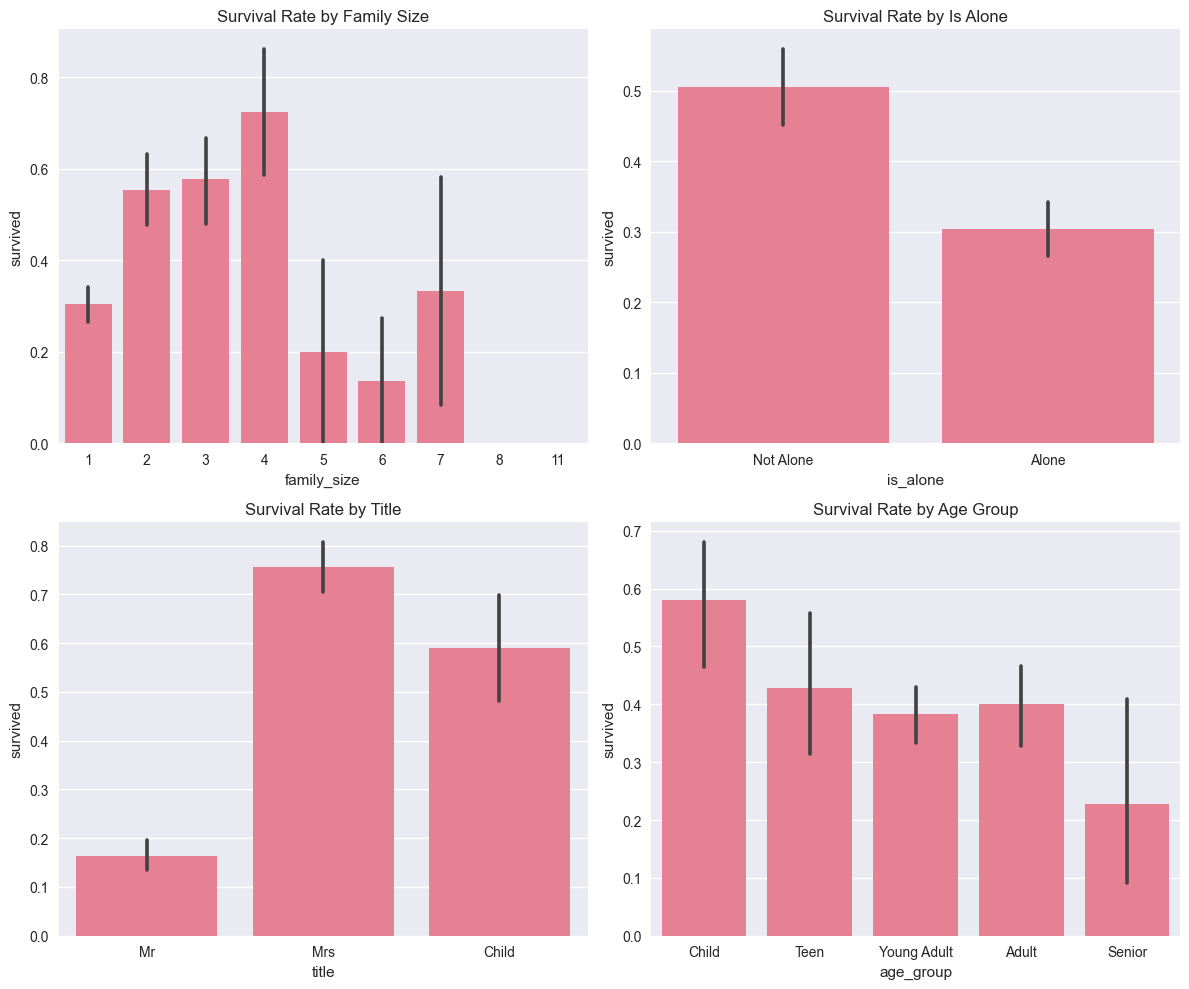

In [42]:
# Visualize the impact of new features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Survival by family size
sns.barplot(data=df_fe, x='family_size', y='survived', ax=axes[0,0])
axes[0,0].set_title('Survival Rate by Family Size')

# Survival by is_alone
sns.barplot(data=df_fe, x='is_alone', y='survived', ax=axes[0,1])
axes[0,1].set_title('Survival Rate by Is Alone')
axes[0,1].set_xticklabels(['Not Alone', 'Alone'])

# Survival by title
sns.barplot(data=df_fe, x='title', y='survived', ax=axes[1,0])
axes[1,0].set_title('Survival Rate by Title')

# Survival by age group
sns.barplot(data=df_fe, x='age_group', y='survived', ax=axes[1,1])
axes[1,1].set_title('Survival Rate by Age Group')

plt.tight_layout()
plt.show()

## 2. Data Categories and Encoding Categorical Variables

### Types of Data:
1. **Numerical**: Continuous or discrete numbers
   - Continuous: age, fare
   - Discrete: sibsp, parch

2. **Categorical**: Limited number of possible values
   - Nominal: No inherent order (sex, embarked)
   - Ordinal: Has inherent order (class, age_group we created)

3. **Text**: Free-form text (name)

4. **Date/Time**: Temporal data

### Why Encode Categorical Variables?
Machine learning algorithms typically work with numerical data. Categorical variables need to be converted to numbers while preserving their meaning.

### Common Encoding Techniques:
1. **Label Encoding**: Assign integer values (0, 1, 2, ...)
2. **One-Hot Encoding**: Create binary columns for each category
3. **Ordinal Encoding**: For ordinal variables with meaningful order
4. **Target Encoding**: Use target variable statistics (risk of leakage!)

In [44]:
# Identify data categories in our dataset
categorical_cols = df_fe.select_dtypes(include=['object', 'category']).columns
numerical_cols = df_fe.select_dtypes(include=['int64', 'float64']).columns

print("Categorical columns:", categorical_cols.tolist())
print("Numerical columns:", numerical_cols.tolist())

# Check unique values in categorical columns
for col in categorical_cols:
    print(f"\n{col}: {df_fe[col].nunique()} unique values")
    print(df_fe[col].value_counts().head())

Categorical columns: ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive', 'title', 'age_group']
Numerical columns: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone', 'fare_per_person']

sex: 2 unique values
sex
male      577
female    314
Name: count, dtype: int64

embarked: 3 unique values
embarked
S    644
C    168
Q     77
Name: count, dtype: int64

class: 3 unique values
class
Third     491
First     216
Second    184
Name: count, dtype: int64

who: 3 unique values
who
man      537
woman    271
child     83
Name: count, dtype: int64

deck: 7 unique values
deck
C    59
B    47
D    33
E    32
A    15
Name: count, dtype: int64

embark_town: 3 unique values
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

alive: 2 unique values
alive
no     549
yes    342
Name: count, dtype: int64

title: 3 unique values
title
Mr       537
Mrs      271
Child     83
Name: count, dtype: int64

age_group: 5 uniq

/var/folders/5j/__t57g5x3xldryts2448pl080000gn/T/ipykernel_9385/1398981184.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_fe.select_dtypes(include=['object', 'category']).columns


### Hands-on: Encoding Categorical Variables

Let's practice different encoding techniques:

In [9]:
# 1. Label Encoding for Ordinal Variables
# Class is ordinal (1st > 2nd > 3rd class)
le = LabelEncoder()
df_encoded = df_fe.copy()

df_encoded['class_encoded'] = le.fit_transform(df_encoded['class'])
print("Class encoding mapping:")
for i, label in enumerate(le.classes_):
    print(f"{label} -> {i}")

# Age group is also ordinal
age_group_order = {'Child': 0, 'Teen': 1, 'Young Adult': 2, 'Adult': 3, 'Senior': 4}
df_encoded['age_group_encoded'] = df_encoded['age_group'].map(age_group_order)

print("\nAge group encoding:")
print(age_group_order)

Class encoding mapping:
First -> 0
Second -> 1
Third -> 2

Age group encoding:
{'Child': 0, 'Teen': 1, 'Young Adult': 2, 'Adult': 3, 'Senior': 4}


In [ ]:
# 2. One-Hot Encoding for Nominal Variables
# Sex and Embarked are nominal
ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' or 'last' to avoid multicollinearity

nominal_cols = ['sex', 'embarked']
encoded_nominal = ohe.fit_transform(df_encoded[nominal_cols])

# Create column names
encoded_col_names = []
for i, col in enumerate(nominal_cols):
    categories = ohe.categories_[i][1:]  # Skip first category due to drop='first'
    encoded_col_names.extend([f"{col}_{cat}" for cat in categories])

# Add encoded columns to dataframe
df_encoded = pd.concat([df_encoded, pd.DataFrame(encoded_nominal, columns=encoded_col_names, index=df_encoded.index)], axis=1)

print("One-hot encoded columns:")
print(encoded_col_names)
print("\nFirst few rows of encoded data:")
print(df_encoded[encoded_col_names].head())

One-hot encoded columns:
['sex_male', 'embarked_Q', 'embarked_S', 'embarked_nan']

First few rows of encoded data:
   sex_male  embarked_Q  embarked_S  embarked_nan
0       1.0         0.0         1.0           0.0
1       0.0         0.0         0.0           0.0
2       0.0         0.0         1.0           0.0
3       0.0         0.0         1.0           0.0
4       1.0         0.0         1.0           0.0


In [11]:
# 3. One-Hot Encoding for Title
title_encoded = ohe.fit_transform(df_encoded[['title']])
title_col_names = [f"title_{cat}" for cat in ohe.categories_[0][1:]]
df_encoded = pd.concat([df_encoded, pd.DataFrame(title_encoded, columns=title_col_names, index=df_encoded.index)], axis=1)

print("Title encoded columns:")
print(title_col_names)

Title encoded columns:
['title_Mr', 'title_Mrs']


## 3. Scaling, Transformations, and Leakage Risks

### Why Scale Features?
- Many ML algorithms are sensitive to feature scales
- Features with larger ranges can dominate the learning
- Improves convergence speed for gradient-based algorithms
- Some algorithms (like KNN, SVM) require similar scales

### Common Scaling Techniques:
1. **Standardization (Z-score)**: Mean=0, Std=1
2. **Min-Max Scaling**: Scale to [0,1] range
3. **Robust Scaling**: Uses median and IQR (robust to outliers)

### Transformations:
- **Log Transform**: For skewed distributions
- **Box-Cox**: Power transformations
- **Square Root**: For count data

### Data Leakage:
Data leakage occurs when information from outside the training set is used to create the model. This leads to overly optimistic performance estimates.

**Common Leakage Sources:**
- Using future information to predict past
- Including target-related features
- Improper preprocessing (scaling with test data)

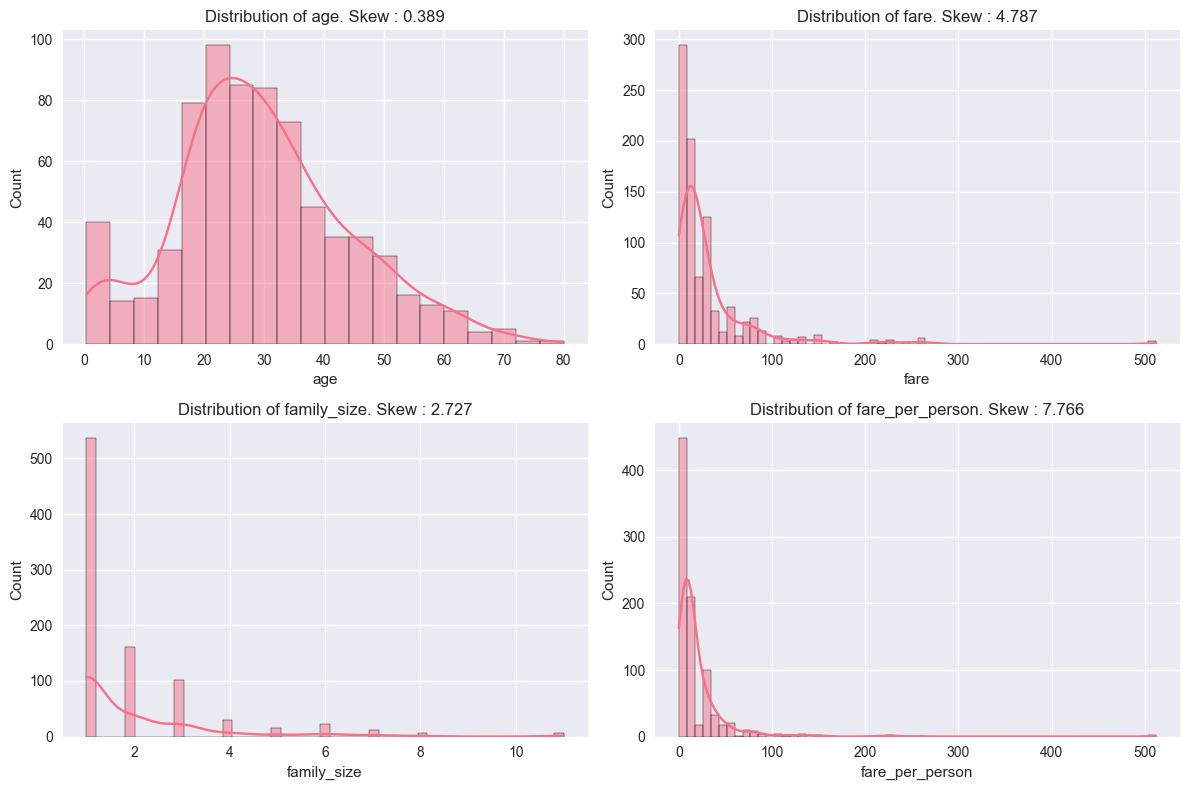

In [ ]:
# Examine distributions of numerical features
numerical_features = ['age', 'fare', 'family_size', 'fare_per_person']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(numerical_features):
    ax = axes[i//2, i%2]
    sns.histplot(data=df_encoded, x=col, ax=ax, kde=True)
    ax.set_title(f'Distribution of {col}. Skew : {df_encoded[col].skew():.3f}')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

### Hands-on: Scaling and Transformations

In [ ]:
# 1. Transformations for skewed data
df_scaled = df_encoded.copy()

# Log transform fare (highly skewed)
df_scaled['fare_log'] = np.log1p(df_scaled['fare'])
df_scaled['fare_per_person_log'] = np.log1p(df_scaled['fare_per_person'])

# Square root transform for family_size
df_scaled['family_size_sqrt'] = np.sqrt(df_scaled['family_size'])

print("Transformed features:")
print("Fare log skewness:", df_scaled['fare_log'].skew())
print("Fare per person log skewness:", df_scaled['fare_per_person_log'].skew())
print("Family size sqrt skewness:", df_scaled['family_size_sqrt'].skew())

Transformed features:
Fare log skewness: 0.3949280095189306
Fare per person log skewness: 0.690259515942463
Family size sqrt skewness: 1.7958854665861346


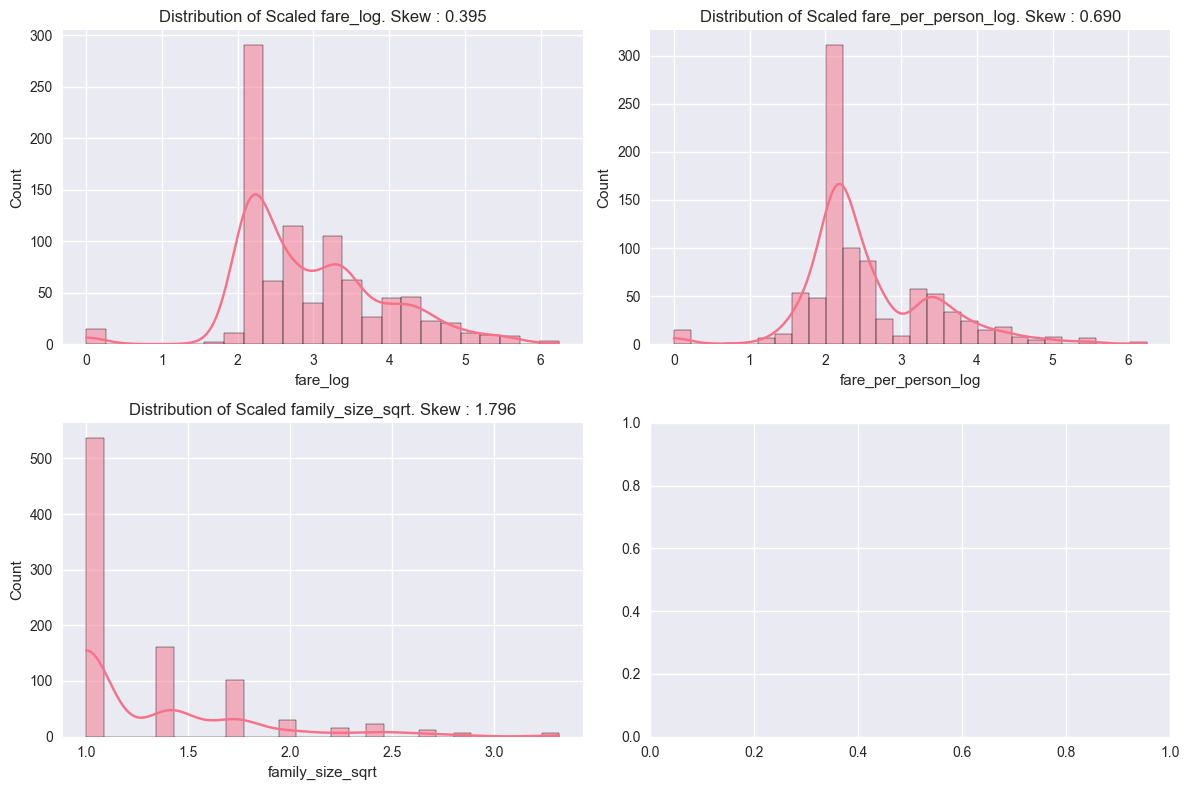

In [ ]:
# Examine distributions of numerical features

transformed_features = ['fare_log', 'fare_per_person_log', 'family_size_sqrt']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(transformed_features):
    ax = axes[i//2, i%2]
    sns.histplot(data=df_scaled, x=col, ax=ax, kde=True)
    ax.set_title(f'Distribution of Transformed {col}. Skew : {df_scaled[col].skew():.3f}')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

In [53]:
# 2. Scaling Techniques
# Select numerical features for scaling
scaled_features = ['age', 'fare_log', 'family_size_sqrt', 'fare_per_person_log']

# Standard Scaler
scaler_std = StandardScaler()
df_scaled[[f'{col}_std' for col in scaled_features]] = scaler_std.fit_transform(df_scaled[scaled_features])

# Min-Max Scaler
scaler_minmax = MinMaxScaler()
df_scaled[[f'{col}_minmax' for col in scaled_features]] = scaler_minmax.fit_transform(df_scaled[scaled_features])

print("Scaling completed. New scaled columns:")
scaled_cols = [col for col in df_scaled.columns if '_std' in col or '_minmax' in col]
print(scaled_cols)

Scaling completed. New scaled columns:
['age_std', 'fare_log_std', 'family_size_sqrt_std', 'fare_per_person_log_std', 'age_minmax', 'fare_log_minmax', 'family_size_sqrt_minmax', 'fare_per_person_log_minmax']


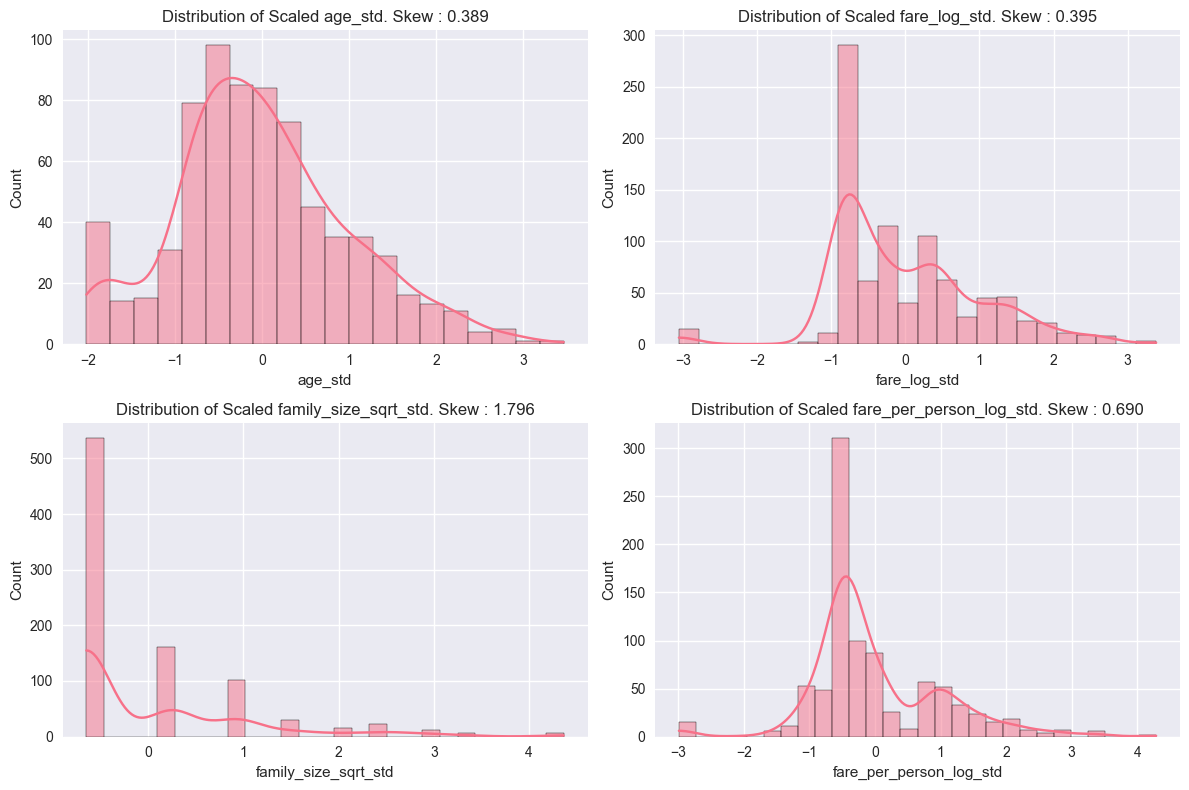

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate([f'{col}_std' for col in scaled_features]):
    ax = axes[i//2, i%2]
    sns.histplot(data=df_scaled, x=col, ax=ax, kde=True)
    ax.set_title(f'Distribution of Standard Scaled {col}. Skew : {df_scaled[col].skew():.3f}')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

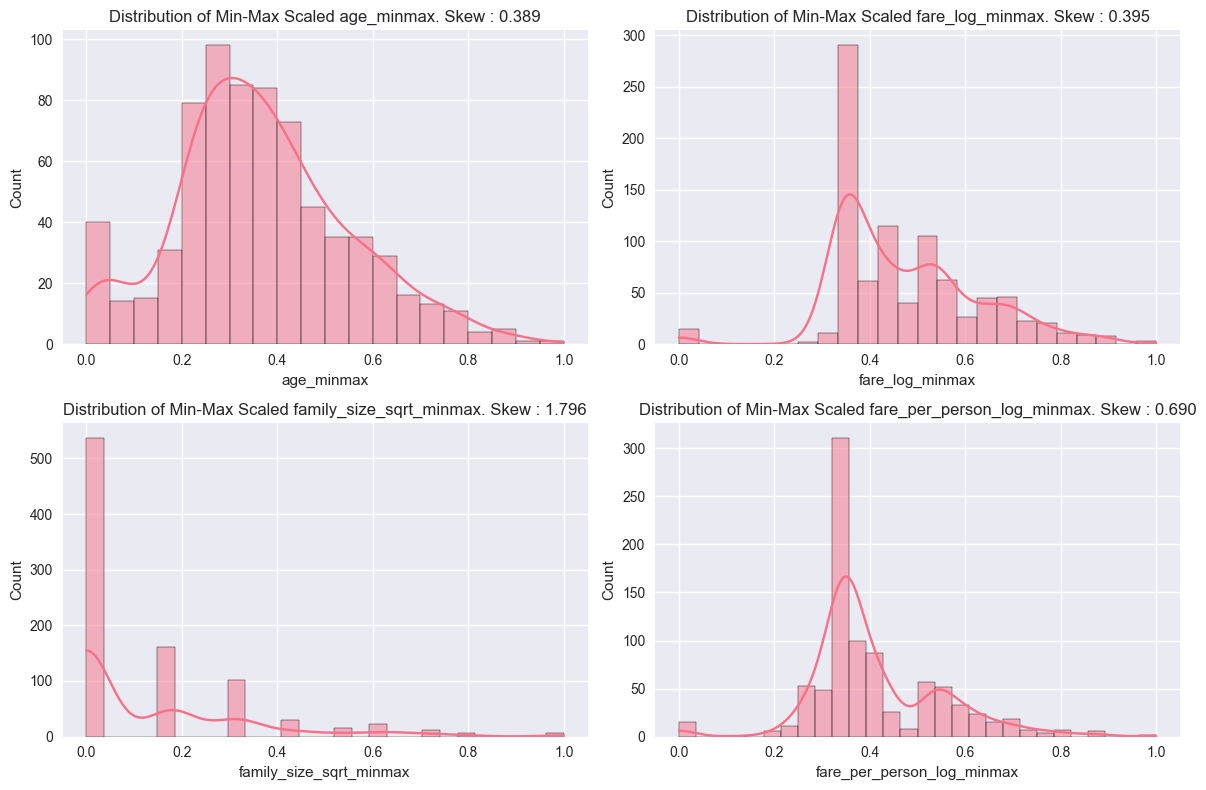

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate([f'{col}_minmax' for col in scaled_features]):
    ax = axes[i//2, i%2]
    sns.histplot(data=df_scaled, x=col, ax=ax, kde=True)
    ax.set_title(f'Distribution of Min-Max Scaled {col}. Skew : {df_scaled[col].skew():.3f}')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

### Hands-on: Understanding Data Leakage

Data leakage can severely bias your model evaluation. Let's demonstrate this with a common mistake: scaling before splitting the data.

In [57]:
# Prepare data for modeling
# Select features and target
features = ['age', 'fare_log', 'family_size_sqrt', 'class_encoded', 'is_alone', 
           'sex_male', 'embarked_Q', 'embarked_S'] + title_col_names

# Drop rows with missing values for simplicity
df_model = df_scaled.dropna(subset=features + ['survived'])

X = df_model[features]
y = df_model['survived']

print("Features for modeling:", features)
print("Dataset shape:", X.shape)

Features for modeling: ['age', 'fare_log', 'family_size_sqrt', 'class_encoded', 'is_alone', 'sex_male', 'embarked_Q', 'embarked_S', 'title_Mr', 'title_Mrs']
Dataset shape: (714, 10)


In [59]:
# Demonstrate Data Leakage: Improper Scaling
# WRONG WAY: Scale on entire dataset before splitting
X_wrong = X.copy()
scaler_wrong = StandardScaler()
X_wrong_scaled = scaler_wrong.fit_transform(X_wrong)

X_train_wrong, X_test_wrong, y_train_wrong, y_test_wrong = train_test_split(
    X_wrong_scaled, y, test_size=0.2, random_state=42, stratify=y)


# CORRECT WAY: Scale only on training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler_correct = StandardScaler()
X_train_scaled = scaler_correct.fit_transform(X_train)
X_test_scaled = scaler_correct.transform(X_test)  # Only transform test data


### Key Takeaways on Data Leakage:
1. **Always split data first** before any preprocessing
2. **Fit transformers only on training data**
3. **Apply fitted transformers to test/validation data**
4. **Be cautious with target-based encodings**
5. **Cross-validation should mimic real-world deployment**

## Summary

In this notebook, we explored:

1. **Feature Engineering**: Creating meaningful features like family size, titles, and age groups
2. **Categorical Encoding**: Label encoding for ordinal data, one-hot encoding for nominal data
3. **Scaling & Transformations**: Handling skewed distributions and scaling features appropriately
4. **Data Leakage Prevention**: Proper preprocessing pipelines to avoid biased model evaluation


### Next Steps:
- Try different feature combinations
- Experiment with other encoding techniques
- Apply these concepts to your own datasets
- Consider automated feature engineering tools